<a href="https://colab.research.google.com/github/clobos/Biologia_2026/blob/main/semana02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tabelas e Gráficos

- Gráfico de barras
- Gráfico de Pizza
- Gráfico de Dispersão
- Boxplot
- Histograma

# Criando dados


In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

dados = pd.DataFrame({
    "id": range(1, 21),
    "sexo": np.random.choice(["Feminino", "Masculino"], 20),
    "tipo_celula": np.random.choice(
        ["Neurônio", "Epitelial", "Muscular", "Conjuntivo"], 20,
        p=[0.3, 0.3, 0.2, 0.2]
    ),  # nominal
    "nivel_expressao_gene": np.random.choice(
        ["Baixo", "Médio", "Alto", "Muito Alto"], 20,
        p=[0.2, 0.3, 0.3, 0.2]
    ),  # ordinal
    "numero_organelas": np.random.randint(50, 200, 20),  # discreta
    "pH_solucao": np.round(np.random.uniform(6.0, 8.0, 20), 1)  # continua
})

dados["nivel_expressao_gene"] = pd.Categorical(
    dados["nivel_expressao_gene"],
    categories=["Baixo", "Médio", "Alto", "Muito Alto"],
    ordered=True
)

dados

,id,sexo,tipo_celula,nivel_expressao_gene,numero_organelas,pH_solucao
0,1,Feminino,Neurônio,Alto,195,6.8
1,2,Masculino,Conjuntivo,Baixo,93,6.6
2,3,Feminino,Conjuntivo,Baixo,63,6.0
3,4,Feminino,Neurônio,Muito Alto,144,6.4
4,5,Feminino,Neurônio,Muito Alto,97,7.4
5,6,Masculino,Neurônio,Muito Alto,64,7.6
6,7,Feminino,Epitelial,Médio,89,7.2
7,8,Feminino,Epitelial,Baixo,131,7.9
8,9,Feminino,Epitelial,Alto,160,7.3
9,10,Masculino,Neurônio,Médio,102,7.8


# Tabelas de frequências

In [2]:
# Frequência para variável nominal (tipo de célula)
freq_celula = dados["tipo_celula"].value_counts()
freq_celula

,count
tipo_celula,
Neurônio,9
Epitelial,7
Conjuntivo,2
Muscular,2


In [3]:
# Frequência relativa (%) (tipo de célula)
freq_celula_rel = dados["tipo_celula"].value_counts(normalize=True)*100
freq_celula_rel

,proportion
tipo_celula,
Neurônio,45.0
Epitelial,35.0
Conjuntivo,10.0
Muscular,10.0


In [4]:
# Frequência para variável ordinal (nível de expressão de gene)
freq_expressao = dados["nivel_expressao_gene"].value_counts()
freq_expressao

,count
nivel_expressao_gene,
Baixo,6
Médio,5
Alto,5
Muito Alto,4


In [5]:
# Frequência para variável discreta (número de organelas)
freq_organela = dados["numero_organelas"].value_counts().sort_index()
freq_organela

,count
numero_organelas,
58,1
63,1
64,2
73,1
89,1
90,1
93,1
94,1
97,1


In [6]:
print('Exemplo de classes com intervalo fechado à esquerda para pH da solução:')
classes_pH_esquerda_fechada = pd.cut(dados["pH_solucao"],
                                       bins=[6.0, 6.5, 7.0, 7.5, 8.0], # Ajuste dos bins para pH
                                       labels=["[6.0-6.5)", "[6.5-7.0)", "[7.0-7.5)", "[7.5-8.0)"],
                                       right=False)

freq_pH_esquerda_fechada = classes_pH_esquerda_fechada.value_counts().sort_index()
freq_pH_esquerda_fechada

Exemplo de classes com intervalo fechado à esquerda para pH da solução:


,count
pH_solucao,
[6.0-6.5),3
[6.5-7.0),6
[7.0-7.5),7
[7.5-8.0),4


# Gráficos mais comuns

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Estilo mais agradável com seaborn
sns.set(style="whitegrid")

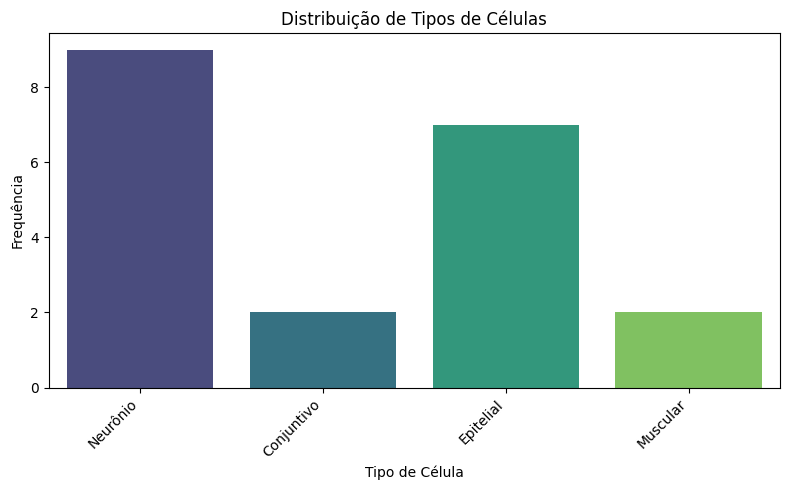

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
# Usando Seaborn (recomendado para iniciantes)
plt.figure(figsize=(8,5))
sns.countplot(data=dados, x="tipo_celula", hue="tipo_celula", palette="viridis", legend=False)
plt.title("Distribuição de Tipos de Células")
plt.xlabel("Tipo de Célula")
plt.ylabel("Frequência")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

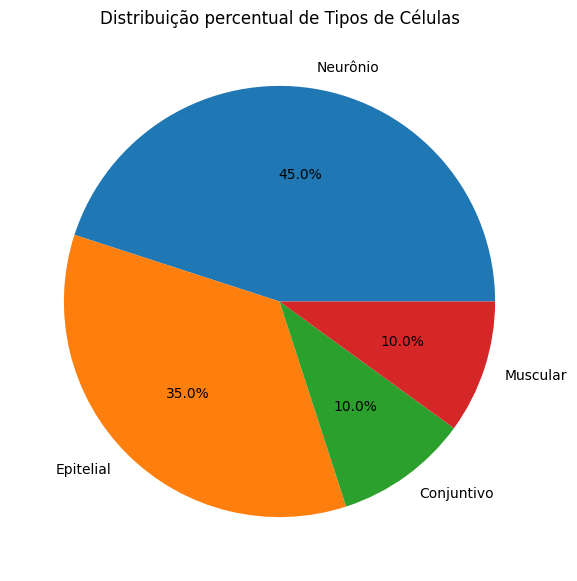

In [14]:
import matplotlib.pyplot as plt
freq_celula = dados["tipo_celula"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(freq_celula,
        labels=freq_celula.index,
        autopct="%.1f%%")
plt.title("Distribuição percentual de Tipos de Células")
plt.show()

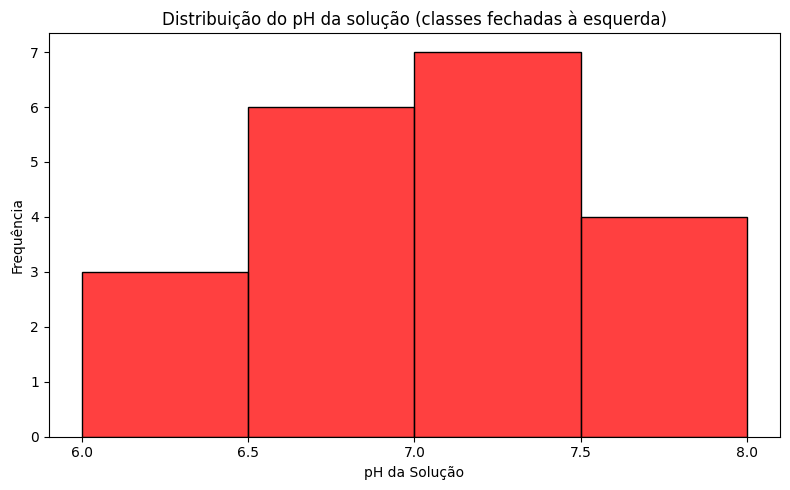

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(data=dados, x="pH_solucao", bins=[6.0, 6.5, 7.0, 7.5, 8.0], kde=False, color="red")
plt.title("Distribuição do pH da solução (classes fechadas à esquerda)")
plt.xlabel("pH da Solução")
plt.ylabel("Frequência")
plt.xticks([6.0, 6.5, 7.0, 7.5, 8.0])
plt.tight_layout()
plt.show()

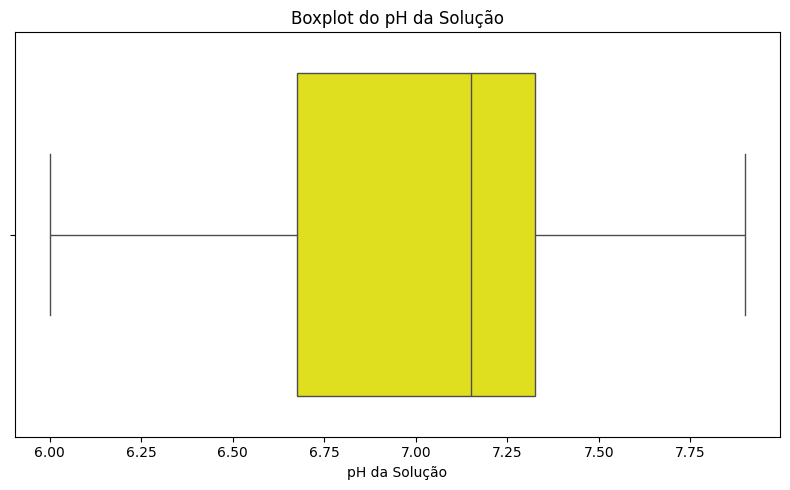

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.boxplot(data=dados, x="pH_solucao", color="yellow")
plt.title("Boxplot do pH da Solução")
plt.xlabel("pH da Solução")
plt.tight_layout()
plt.show()

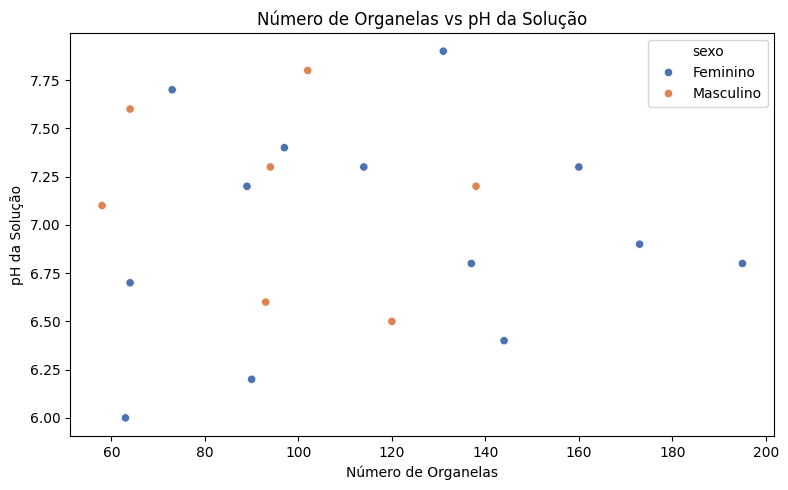

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.scatterplot(data=dados, x="numero_organelas", y="pH_solucao", hue="sexo", palette="deep")
plt.title("Número de Organelas vs pH da Solução")
plt.xlabel("Número de Organelas")
plt.ylabel("pH da Solução")
plt.tight_layout()
plt.show()

In [18]:
import plotly.express as px
fig = px.scatter(dados,
                 x="numero_organelas",
                 y="pH_solucao",
                 color="sexo",
                 title="Número de Organelas vs pH da Solução (interativo)")
fig.show()